# Model in Linear Regression

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme()

In [19]:
X = np.array([1, 3, 4, 6, 7])  # years of experience
y = np.array([15, 35, 45, 65, 75])  # salary (in thousands)

<Axes: >

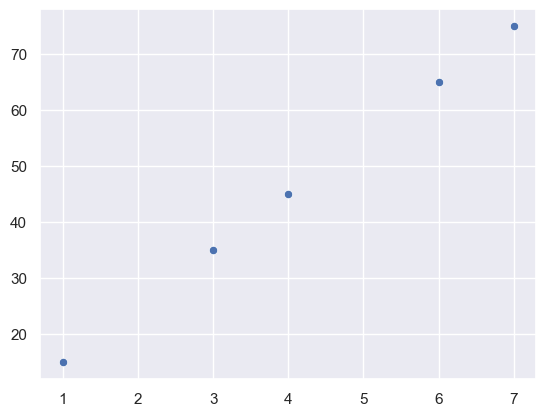

In [20]:
sns.scatterplot(x=X, y=y)

In [21]:
def make_prediction(X, y, w, b):
    m = X.shape[0]

    pred_list = np.zeros((m,))
    
    for i in range(m):
        pred_list[i] = w * X[i] + b
    return pred_list

[0. 0. 0. 0. 0.]


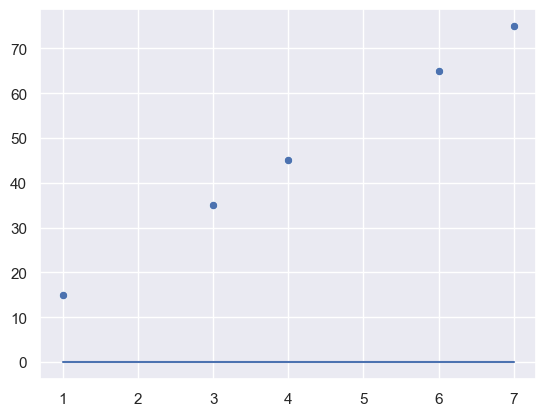

In [22]:
prediction = make_prediction(X, y, 0, 0)
print(prediction)

sns.scatterplot(x=X, y=y)
plt.plot(X, prediction)
plt.show()

[1. 3. 4. 6. 7.]


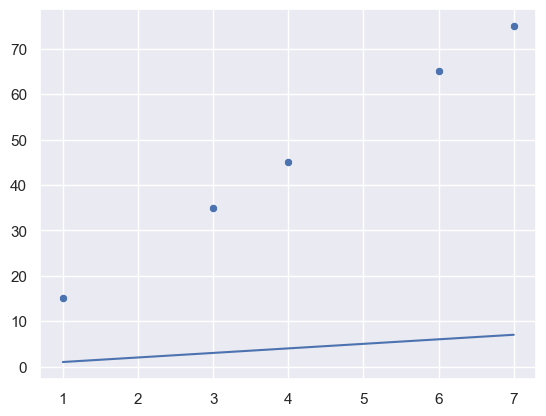

In [23]:
prediction = make_prediction(X, y, 1, 0)
print(prediction)

sns.scatterplot(x=X, y=y)
plt.plot(X, prediction)
plt.show()

[15. 35. 45. 65. 75.]


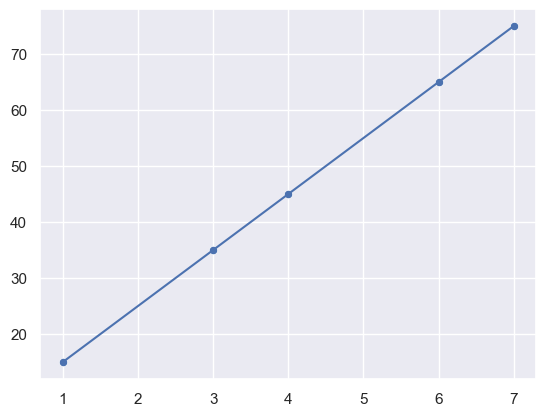

In [24]:
prediction = make_prediction(X, y, 10, 5)
print(prediction)

sns.scatterplot(x=X, y=y)
plt.plot(X, prediction)
plt.show()

# Implementation of cost function

In [25]:
def compute_cost(X, y, w, b):
    m = X.shape[0] # nuber of data point

    cost = 0.0
    
    for i in range(m):
        prediction = w * X[i] + b
        error = prediction - y[i]
        error_squared = error ** 2
        cost = cost + error_squared

    cost = cost / (2*m)

    return cost

[0. 0. 0. 0. 0.]


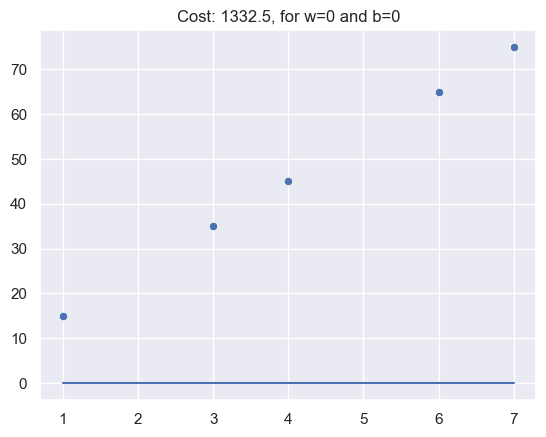

In [26]:
w = 0
b = 0

prediction = make_prediction(X, y, w=w, b=b)
print(prediction)

sns.scatterplot(x=X, y=y)
plt.plot(X, prediction)
plt.title(f"Cost: {compute_cost(X, y, w=w, b=b)}, for w={w} and b={b}")

plt.show()

[15. 35. 45. 65. 75.]


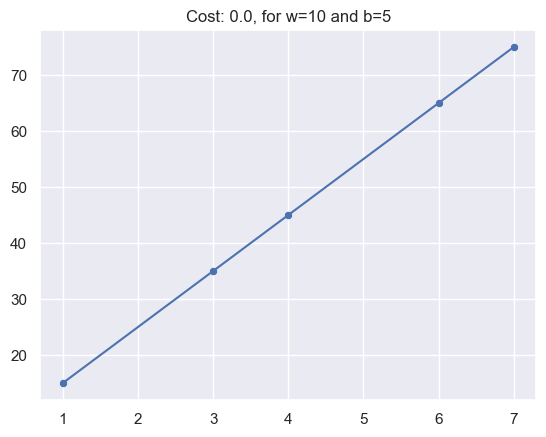

In [27]:
w = 10
b = 5

prediction = make_prediction(X, y, w=w, b=b)
print(prediction)

sns.scatterplot(x=X, y=y)
plt.plot(X, prediction)
plt.title(f"Cost: {compute_cost(X, y, w=w, b=b)}, for w={w} and b={b}")

plt.show()

# Idea of Minimizing the cost function

Text(0, 0.5, 'Cost--> J(w)')

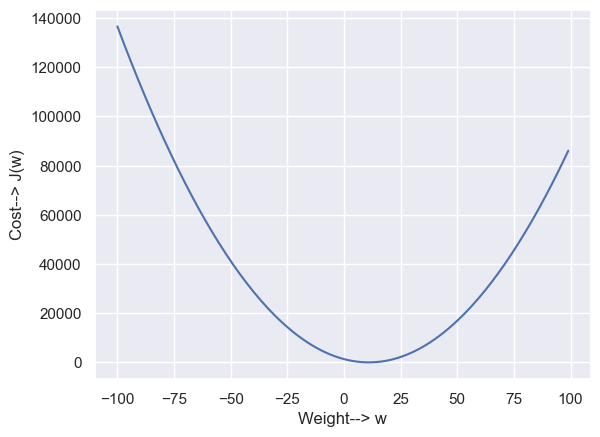

In [28]:
w = []
cost = []

for i in range(-100, 100):
    cost_i = compute_cost(X, y, w=i, b=0)
    w.append(i)
    cost.append(cost_i)

plt.plot(w, cost)
plt.xlabel("Weight--> w")
plt.ylabel("Cost--> J(w)")

# Calcualation of Gradient

In [29]:
def calculate_gradient(X, y, w, b):
    m = X.shape[0] # nuber of data point

    dj_dw = 0
    dj_db = 0
    
    for i in range(m):
        prediction = w * X[i] + b
        error = prediction - y[i]
        dj_dw = dj_dw + (error * X[i])
        dj_db = dj_db + error

    dj_dw = dj_dw / m
    dj_db = dj_db / m

    return dj_dw, dj_db
    

In [30]:
calculate_gradient(X, y, w=10, b=5)

(np.float64(0.0), np.float64(0.0))

# Applying Gradient Descent to minimize cost and Final Prediction

In [31]:
def gradient_descent(X, y, w_input, b_input, max_iter, alpha=0.01):
  """Automates the tuning of w and b to minimize cost"""
  w = w_input
  b = b_input
  cost_memo = []
  iteration = []

  for i in range(max_iter):
    # 1. Calculate the gradients (the slope)
    dj_dw, dj_db = calculate_gradient(X, y, w, b)

    # 2. Update parameters by taking a small step (alpha) against the gradient
    w = w - alpha * dj_dw
    b = b - alpha * dj_db

    # 3. Track progress by saving the cost
    cost = compute_cost(X, y, w, b)
    cost_memo.append(cost)
    iteration.append(i)

    # Log the status every 100 steps
    if i % 100 == 0:
      print(f"Iteration {i}: Cost {cost:0.4f}, w: {w:0.4f}, b: {b:0.4f}")

  return w, b, cost_memo, iteration

In [32]:
# Run gradient descent and store the results in w_final and b_final
w_final, b_final, cost_memo, iter_list = gradient_descent(X, y, w_input=0, b_input=0, max_iter=10000, alpha=0.01)

Iteration 0: Cost 790.3717, w: 2.4300, b: 0.4700
Iteration 100: Cost 0.6120, w: 10.4659, b: 2.5593
Iteration 200: Cost 0.4115, w: 10.3821, b: 2.9986
Iteration 300: Cost 0.2767, w: 10.3133, b: 3.3588
Iteration 400: Cost 0.1861, w: 10.2569, b: 3.6542
Iteration 500: Cost 0.1251, w: 10.2107, b: 3.8965
Iteration 600: Cost 0.0841, w: 10.1727, b: 4.0951
Iteration 700: Cost 0.0566, w: 10.1416, b: 4.2580
Iteration 800: Cost 0.0380, w: 10.1162, b: 4.3915
Iteration 900: Cost 0.0256, w: 10.0952, b: 4.5010
Iteration 1000: Cost 0.0172, w: 10.0781, b: 4.5909
Iteration 1100: Cost 0.0116, w: 10.0640, b: 4.6645
Iteration 1200: Cost 0.0078, w: 10.0525, b: 4.7249
Iteration 1300: Cost 0.0052, w: 10.0431, b: 4.7744
Iteration 1400: Cost 0.0035, w: 10.0353, b: 4.8150
Iteration 1500: Cost 0.0024, w: 10.0290, b: 4.8483
Iteration 1600: Cost 0.0016, w: 10.0237, b: 4.8756
Iteration 1700: Cost 0.0011, w: 10.0195, b: 4.8980
Iteration 1800: Cost 0.0007, w: 10.0160, b: 4.9164
Iteration 1900: Cost 0.0005, w: 10.0131, b

# Final Results & Prediction

Optimized w: 10.0000, b: 5.0000


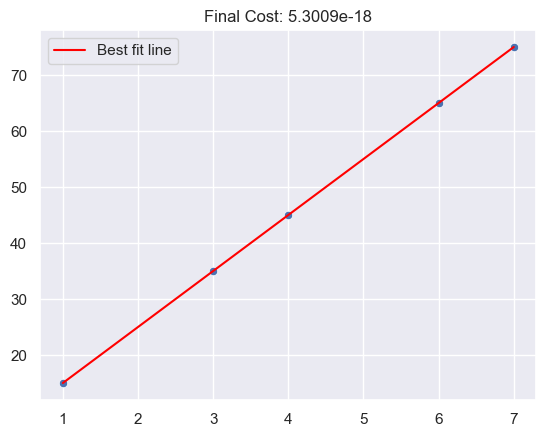

In [33]:
print(f"Optimized w: {w_final:0.4f}, b: {b_final:0.4f}")

# Get final predictions based on optimized parameters
final_preds = make_prediction(X, y, w=w_final, b=b_final)

# Visualize the final best-fit line
sns.scatterplot(x=X, y=y)
plt.plot(X, final_preds, color='red', label='Best fit line')
plt.title(f"Final Cost: {compute_cost(X, y, w_final, b_final):0.4e}")
plt.legend()
plt.show()